# Training Matrix - Profile Matching Data\n\nข้อมูล training data สำหรับ profile matching ข้าม platform\n- **1.profile.data** = Google+ profiles เดี่ยว\n- **2.profile.data** = คู่ profiles ข้าม platform (Google_Insta, Google_Twitter, Insta_Twitter)\n- **label = 1** → คนเดียวกัน, **label = 0** → คนละคน

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Per-Pair Training Data (n×n matrix แยกแต่ละคู่ platform)

In [6]:
# โหลด flat training data แยกแต่ละ pair
pair_names = ["Google_Insta", "Google_Twitter", "Insta_Twitter"]
pair_dfs = {}

for pair in pair_names:
    path = f"{pair}/{pair}_training_flat.csv"
    df = pd.read_csv(path)
    pair_dfs[pair] = df
    n = int(np.sqrt(len(df)))
    pos = (df["label"] == 1).sum()
    neg = (df["label"] == 0).sum()
    print(f"{pair}: {n} profiles → {len(df):,} pairs (pos={pos:,}, neg={neg:,}, ratio=1:{neg//pos})")

print(f"\nรวมทั้งหมด: {sum(len(d) for d in pair_dfs.values()):,} pairs")

Google_Insta: 614 profiles → 376,996 pairs (pos=614, neg=376,382, ratio=1:613)
Google_Twitter: 2974 profiles → 8,844,676 pairs (pos=2,974, neg=8,841,702, ratio=1:2973)
Insta_Twitter: 2451 profiles → 6,007,401 pairs (pos=2,451, neg=6,004,950, ratio=1:2450)

รวมทั้งหมด: 15,229,073 pairs


In [7]:
# ดูตัวอย่างข้อมูล
pair_dfs["Google_Insta"].head(10)

,pair_type,googlePlus_idx,googlePlus_folder,googlePlus_userName,googlePlus_fullName,instagram_idx,instagram_folder,instagram_userName,instagram_fullName,username_exact_match,fullname_exact_match,username_bigram_jaccard,fullname_bigram_jaccard,merged_bigram_jaccard,label
0,Google_Insta,0,ANeal,andrewneal,andrew neal,0,ANeal,kidsdirectorytulsa,kids' directory tulsa,0,0,0.040000,0.034483,0.027778,1
1,Google_Insta,0,ANeal,andrewneal,andrew neal,1,AlexYurasov,alexyurasov,alexander yurasov,0,0,0.055556,0.130435,0.142857,0
2,Google_Insta,0,ANeal,andrewneal,andrew neal,2,Amfsharkspain96,skinned_man_,antonio martín,0,0,0.111111,0.045455,0.088235,0
3,Google_Insta,0,ANeal,andrewneal,andrew neal,3,AndyPeor,miradero,giselle,0,0,0.000000,0.000000,0.000000,0
4,Google_Insta,0,ANeal,andrewneal,andrew neal,4,ArielMarques,ariel.marques,⎈ ariel marques ⎈,0,0,0.000000,0.000000,0.071429,0
5,Google_Insta,0,ANeal,andrewneal,andrew neal,5,ArtSchultz,artschultz13,art schultz,0,0,0.000000,0.000000,0.037037,0
6,Google_Insta,0,ANeal,andrewneal,andrew neal,6,BethSanders,mssandersecs,beth sanders,0,0,0.111111,0.105263,0.068966,0
7,Google_Insta,0,ANeal,andrewneal,andrew neal,7,BethanyJJMiller,bethanyjjmiller,bethany miller,0,0,0.045455,0.045455,0.033333,0
8,Google_Insta,0,ANeal,andrewneal,andrew neal,8,BridgetChristian,shinymama,bridget,0,0,0.000000,0.000000,0.000000,0
9,Google_Insta,0,ANeal,andrewneal,andrew neal,9,BrydenMcGrath,bryden13,nick bryden,0,0,0.000000,0.000000,0.038462,0


## 2. Feature Distribution: Label=1 vs Label=0

In [8]:
# รวม data ทุก pair เพื่อวิเคราะห์ภาพรวม
all_flat = pd.read_csv("all_pairs_training_flat.csv")
print(f"All pairs flat: {len(all_flat):,} rows")
print(f"Columns: {list(all_flat.columns)}")

feature_cols = ["username_exact_match", "fullname_exact_match",
                "username_bigram_jaccard", "fullname_bigram_jaccard", 
                "merged_bigram_jaccard"]

print("\n--- Feature means by label ---")
print(all_flat.groupby("label")[feature_cols].mean().round(4).T)

/var/folders/ht/_lrx9n5s0539yfctp63z0yz00000gn/T/ipykernel_91843/3138620702.py:2: DtypeWarning: Columns (2,3,4,6,7,8,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  all_flat = pd.read_csv("all_pairs_training_flat.csv")


All pairs flat: 15,229,073 rows
Columns: ['pair_type', 'googlePlus_idx', 'googlePlus_folder', 'googlePlus_userName', 'googlePlus_fullName', 'instagram_idx', 'instagram_folder', 'instagram_userName', 'instagram_fullName', 'username_exact_match', 'fullname_exact_match', 'username_bigram_jaccard', 'fullname_bigram_jaccard', 'merged_bigram_jaccard', 'label', 'twitter_idx', 'twitter_folder', 'twitter_userName', 'twitter_fullName']

--- Feature means by label ---
label                         0       1
username_exact_match     0.0000  0.0190
fullname_exact_match     0.0000  0.4512
username_bigram_jaccard  0.0242  0.5318
fullname_bigram_jaccard  0.0306  0.6405
merged_bigram_jaccard    0.0386  0.5845


/var/folders/ht/_lrx9n5s0539yfctp63z0yz00000gn/T/ipykernel_91843/687186305.py:16: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ht/_lrx9n5s0539yfctp63z0yz00000gn/T/ipykernel_91843/687186305.py:16: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ht/_lrx9n5s0539yfctp63z0yz00000gn/T/ipykernel_91843/687186305.py:16: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/tm/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tm/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

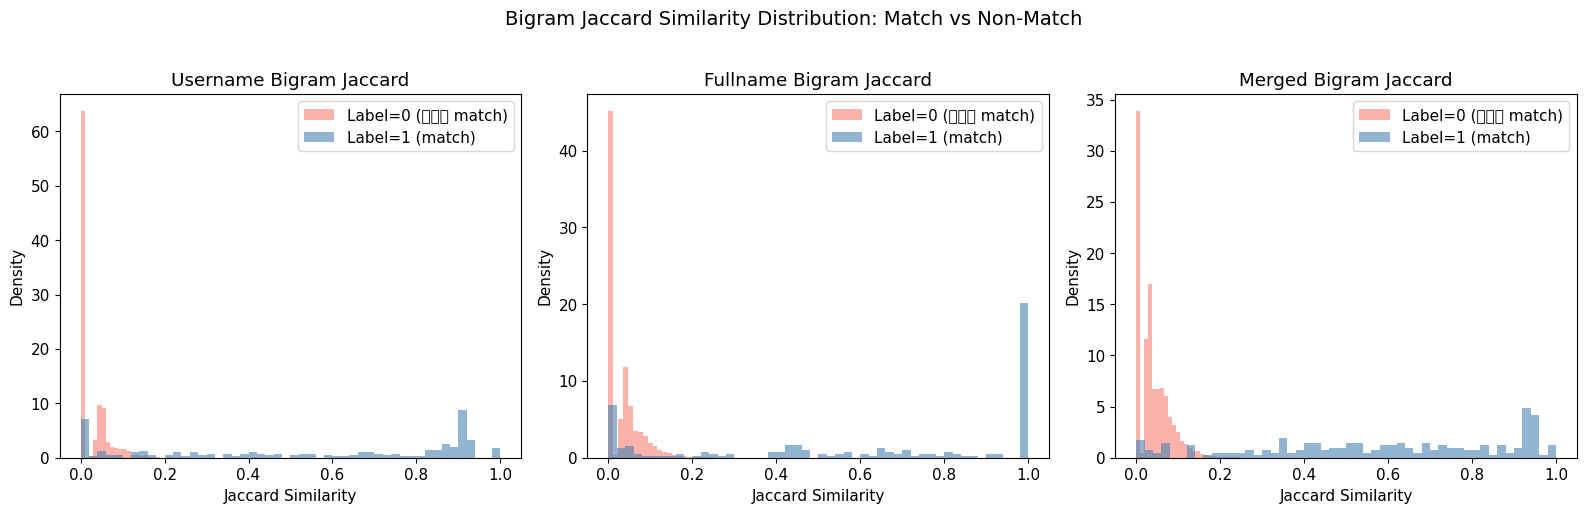

In [9]:
# Distribution ของ bigram similarity features แยก label
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["username_bigram_jaccard", "fullname_bigram_jaccard", "merged_bigram_jaccard"]):
    # Sample เพื่อไม่ให้ plot ช้า
    sample = all_flat.sample(min(500_000, len(all_flat)), random_state=42)
    
    ax.hist(sample.loc[sample["label"]==0, col], bins=50, alpha=0.6, label="Label=0 (ไม่ match)", density=True, color="salmon")
    ax.hist(sample.loc[sample["label"]==1, col], bins=50, alpha=0.6, label="Label=1 (match)", density=True, color="steelblue")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Jaccard Similarity")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Bigram Jaccard Similarity Distribution: Match vs Non-Match", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

/var/folders/ht/_lrx9n5s0539yfctp63z0yz00000gn/T/ipykernel_91843/791172670.py:14: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ht/_lrx9n5s0539yfctp63z0yz00000gn/T/ipykernel_91843/791172670.py:14: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ht/_lrx9n5s0539yfctp63z0yz00000gn/T/ipykernel_91843/791172670.py:14: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


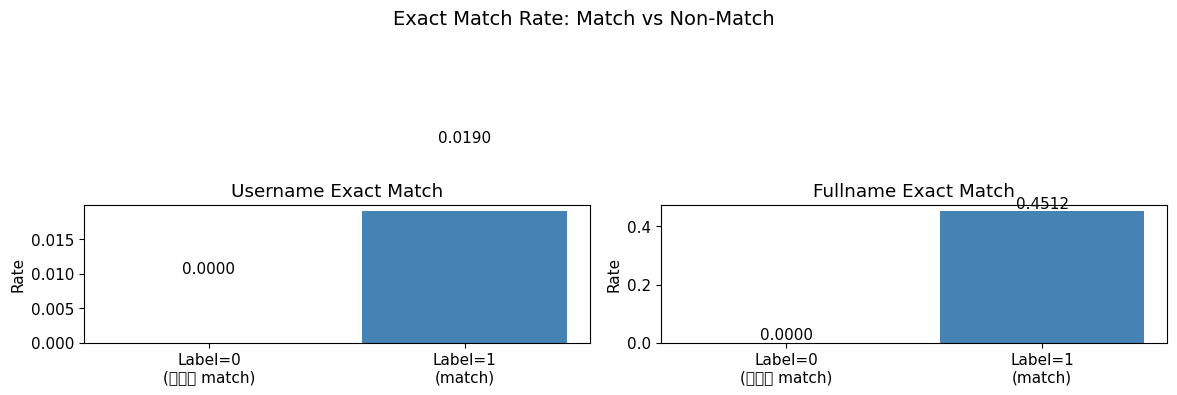

In [10]:
# Exact match rate แยก label
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ["username_exact_match", "fullname_exact_match"]):
    rates = all_flat.groupby("label")[col].mean()
    bars = ax.bar(["Label=0\n(ไม่ match)", "Label=1\n(match)"], rates.values, color=["salmon", "steelblue"])
    ax.set_title(col.replace("_", " ").title())
    ax.set_ylabel("Rate")
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f"{val:.4f}", ha='center', fontsize=11)

plt.suptitle("Exact Match Rate: Match vs Non-Match", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Per-Pair Breakdown

In [11]:
# Feature means แยกแต่ละ pair
for pair_name, df in pair_dfs.items():
    print(f"\n{'='*50}")
    print(f"  {pair_name}")
    print(f"{'='*50}")
    print(f"  Total pairs: {len(df):,}")
    print(f"  Positive (label=1): {(df['label']==1).sum():,}")
    print(f"  Negative (label=0): {(df['label']==0).sum():,}")
    print()
    print(df.groupby("label")[feature_cols].mean().round(4).T)
    print()


  Google_Insta
  Total pairs: 376,996
  Positive (label=1): 614
  Negative (label=0): 376,382

label                         0       1
username_exact_match     0.0000  0.1873
fullname_exact_match     0.0000  0.4674
username_bigram_jaccard  0.0278  0.4198
fullname_bigram_jaccard  0.0321  0.6441
merged_bigram_jaccard    0.0405  0.5584


  Google_Twitter
  Total pairs: 8,844,676
  Positive (label=1): 2,974
  Negative (label=0): 8,841,702

label                         0       1
username_exact_match     0.0000  0.0000
fullname_exact_match     0.0000  0.4361
username_bigram_jaccard  0.0264  0.4033
fullname_bigram_jaccard  0.0324  0.6355
merged_bigram_jaccard    0.0397  0.5274


  Insta_Twitter
  Total pairs: 6,007,401
  Positive (label=1): 2,451
  Negative (label=0): 6,004,950

label                         0       1
username_exact_match     0.0000  0.0000
fullname_exact_match     0.0000  0.4655
username_bigram_jaccard  0.0207  0.7158
fullname_bigram_jaccard  0.0280  0.6456
merged_bigram_j

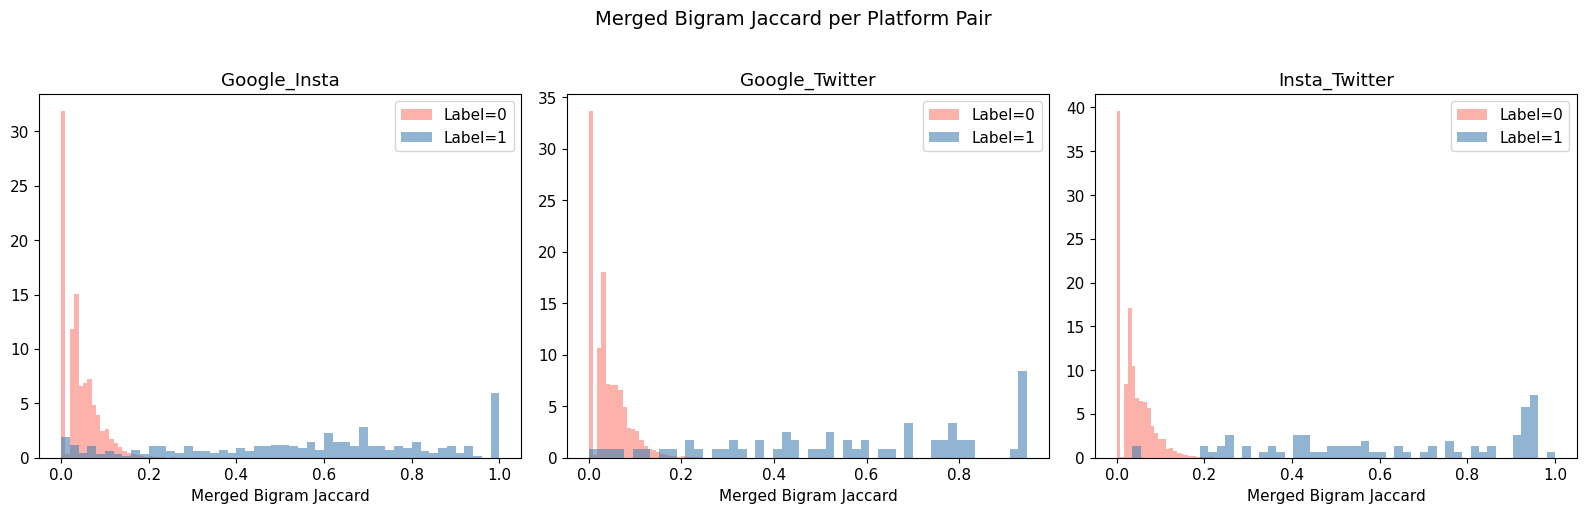

In [12]:
# เปรียบเทียบ bigram similarity distribution ข้าม pair
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, pair_name in zip(axes, pair_names):
    df = pair_dfs[pair_name]
    sample = df.sample(min(200_000, len(df)), random_state=42)
    
    ax.hist(sample.loc[sample["label"]==0, "merged_bigram_jaccard"], bins=50, alpha=0.6, 
            label="Label=0", density=True, color="salmon")
    ax.hist(sample.loc[sample["label"]==1, "merged_bigram_jaccard"], bins=50, alpha=0.6, 
            label="Label=1", density=True, color="steelblue")
    ax.set_title(pair_name)
    ax.set_xlabel("Merged Bigram Jaccard")
    ax.legend()

plt.suptitle("Merged Bigram Jaccard per Platform Pair", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. n×n Label Matrix Heatmap (ตัวอย่าง)

Label matrix shape: (614, 614)


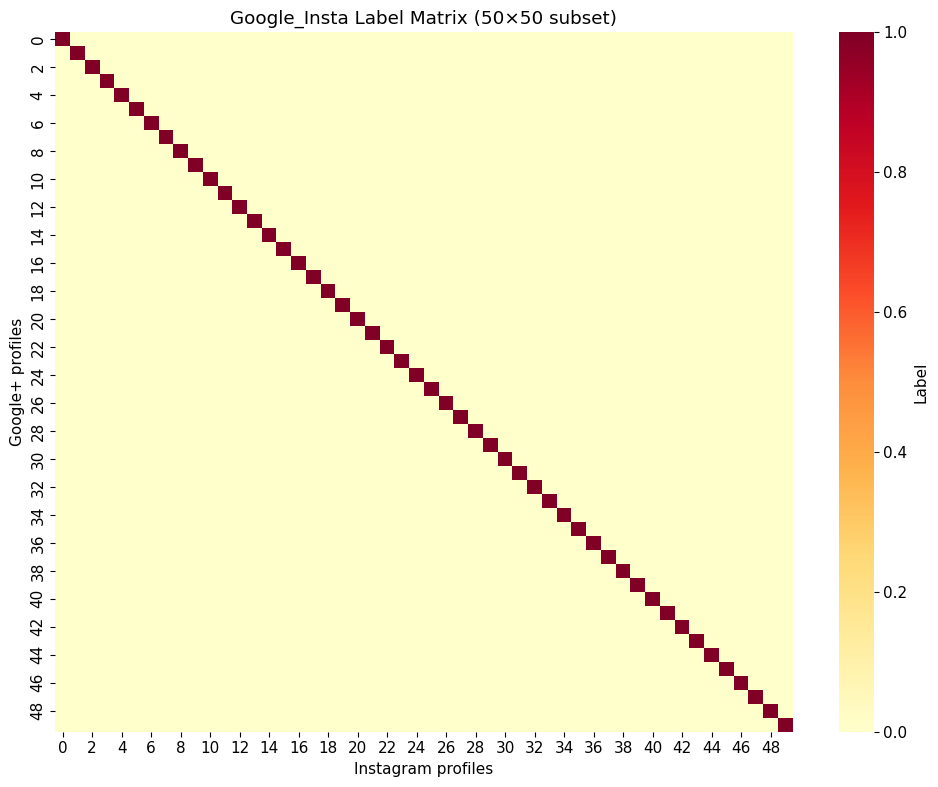

In [13]:
# ดู label matrix (แนวทแยง = 1, ที่เหลือ = 0)
label_mat = pd.read_csv("Google_Insta/Google_Insta_label_matrix.csv", index_col=0)
print(f"Label matrix shape: {label_mat.shape}")

# แสดง heatmap ส่วนเล็กๆ (50×50 แรก)
subset = label_mat.iloc[:50, :50]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(subset.values, cmap="YlOrRd", cbar_kws={"label": "Label"}, ax=ax)
ax.set_title("Google_Insta Label Matrix (50×50 subset)")
ax.set_xlabel("Instagram profiles")
ax.set_ylabel("Google+ profiles")
plt.tight_layout()
plt.show()

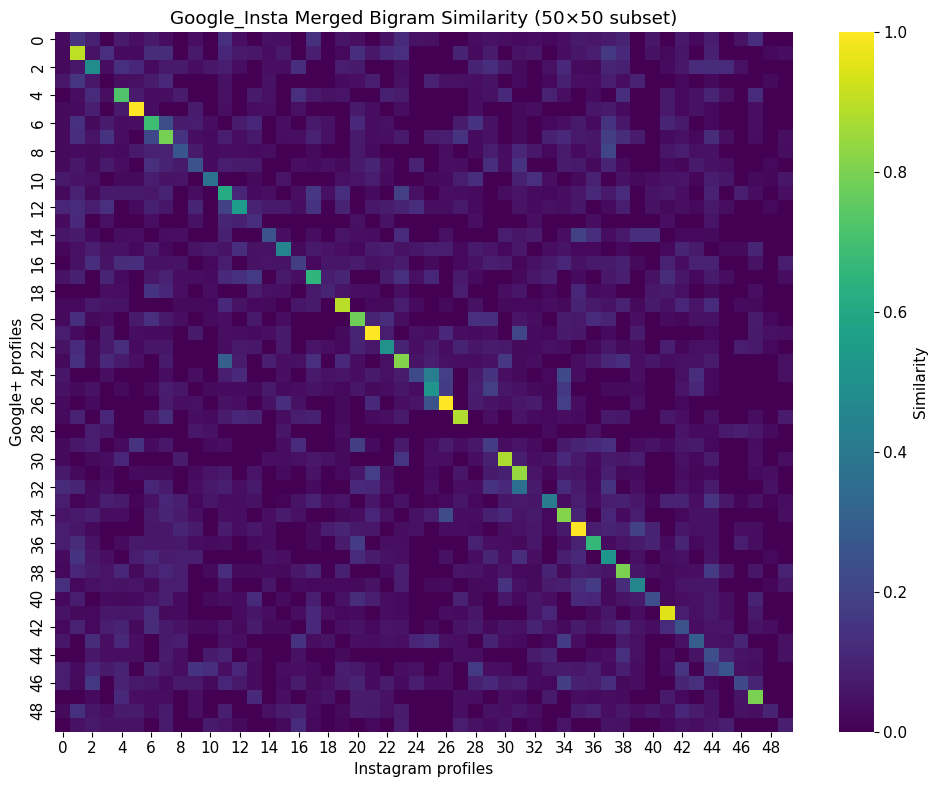

In [14]:
# Similarity matrix heatmap (merged bigram)
sim_mat = pd.read_csv("Google_Insta/Google_Insta_merged_bigram_sim_matrix.csv", index_col=0)

subset_sim = sim_mat.iloc[:50, :50]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(subset_sim.values, cmap="viridis", vmin=0, vmax=1, cbar_kws={"label": "Similarity"}, ax=ax)
ax.set_title("Google_Insta Merged Bigram Similarity (50×50 subset)")
ax.set_xlabel("Instagram profiles")
ax.set_ylabel("Google+ profiles")
plt.tight_layout()
plt.show()

## 5. Combined All-Platforms Training Data

In [15]:
# Combined training data (positive + sampled negative, balanced)
combined = pd.read_csv("combined_all_platforms_training.csv")
print(f"Combined training data: {len(combined):,} rows")
print(f"Label distribution:")
print(combined["label"].value_counts())
print(f"\nRatio positive:negative = 1:{(combined['label']==0).sum() // (combined['label']==1).sum()}")
combined.head()

Combined training data: 72,468 rows
Label distribution:
label
0    60390
1    12078
Name: count, dtype: int64

Ratio positive:negative = 1:5


,profile_a_idx,profile_a_platform,profile_a_folder,profile_a_pair_source,profile_a_userName,profile_a_fullName,profile_b_idx,profile_b_platform,profile_b_folder,profile_b_pair_source,profile_b_userName,profile_b_fullName,username_exact_match,fullname_exact_match,username_bigram_jaccard,fullname_bigram_jaccard,merged_bigram_jaccard,same_platform,label
0,3862,twitter,heatherfeather32,Google_Twitter,@spokanewebsite,heather wood,128,googlePlus,SerenBorvali,Google_Insta,serenborval,seren borval,0,0,0.000000,0.050000,0.025641,0,0
1,9573,instagram,jessebussard,Insta_Twitter,jessebussard,jesse bussard,9572,twitter,jessebussard,Insta_Twitter,@cowgirljesse,jesse bussard,0,1,0.222222,1.000000,0.545455,0,1
2,4079,googlePlus,iwantcrystalcouturecom,Google_Twitter,crystalcouture,crystal couture,7029,googlePlus,wilder80,Google_Twitter,wilderbiral,wilder biral,0,0,0.045455,0.041667,0.071429,1,0
3,5604,googlePlus,nickkenyon,Google_Twitter,nickkenyonfoto,nick kenyon,3036,twitter,davidaranzabal,Google_Twitter,@fx_foraliving,david aranzabal,0,0,0.040000,0.000000,0.023810,0,0
4,432,googlePlus,dianamahmoud,Google_Insta,dianamahmoud,diana mahmoud,8026,twitter,ashleysky,Insta_Twitter,@theashleysky,ashley sky,0,0,0.000000,0.000000,0.000000,0,0


In [16]:
# Profile index
prof_idx = pd.read_csv("combined_profile_index.csv")
print(f"Total unique profiles: {len(prof_idx)}")
print(f"\nPlatform breakdown:")
print(prof_idx["platform"].value_counts())
print(f"\nPair source breakdown:")
print(prof_idx["pair_source"].value_counts())

Total unique profiles: 12078

Platform breakdown:
platform
twitter       5425
googlePlus    3588
instagram     3065
Name: count, dtype: int64

Pair source breakdown:
pair_source
Google_Twitter    5948
Insta_Twitter     4902
Google_Insta      1228
Name: count, dtype: int64


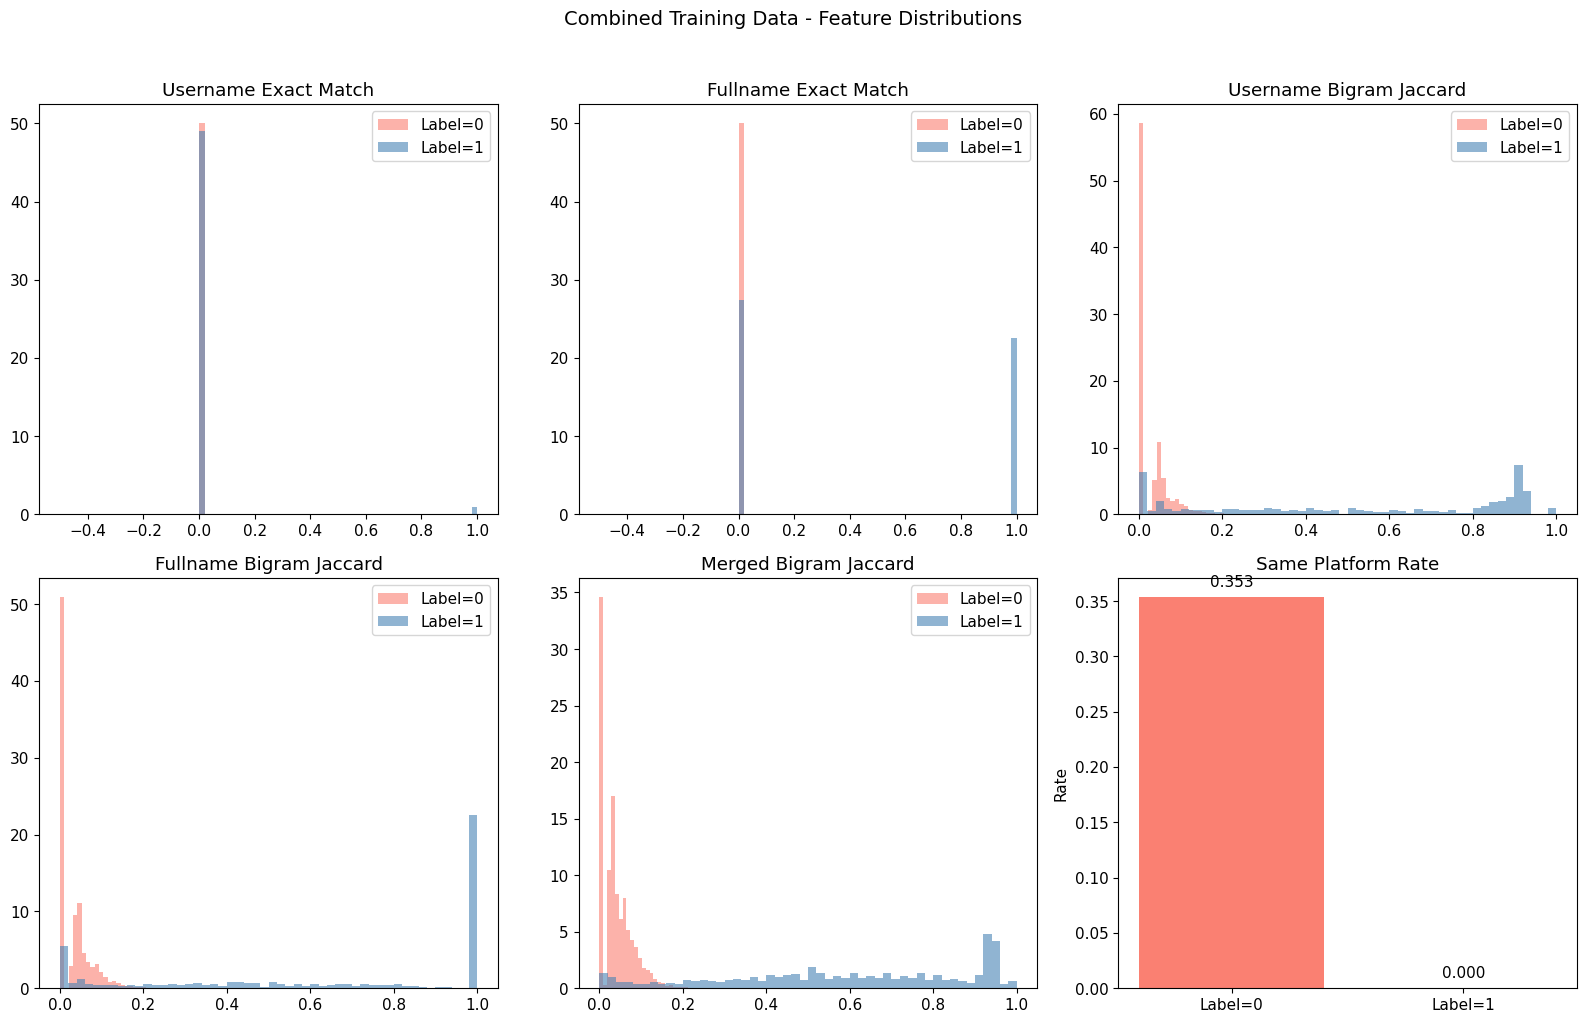

In [17]:
# Combined features comparison
combined_features = ["username_exact_match", "fullname_exact_match",
                     "username_bigram_jaccard", "fullname_bigram_jaccard",
                     "merged_bigram_jaccard"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes[:5], combined_features):
    pos_vals = combined.loc[combined["label"]==1, col]
    neg_vals = combined.loc[combined["label"]==0, col]
    
    ax.hist(neg_vals, bins=50, alpha=0.6, label="Label=0", density=True, color="salmon")
    ax.hist(pos_vals, bins=50, alpha=0.6, label="Label=1", density=True, color="steelblue")
    ax.set_title(col.replace("_", " ").title())
    ax.legend()

# Cross-platform indicator
ax = axes[5]
rates = combined.groupby("label")["same_platform"].mean()
bars = ax.bar(["Label=0", "Label=1"], rates.values, color=["salmon", "steelblue"])
ax.set_title("Same Platform Rate")
ax.set_ylabel("Rate")
for bar, val in zip(bars, rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f"{val:.3f}", ha='center', fontsize=11)

plt.suptitle("Combined Training Data - Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Feature Correlation

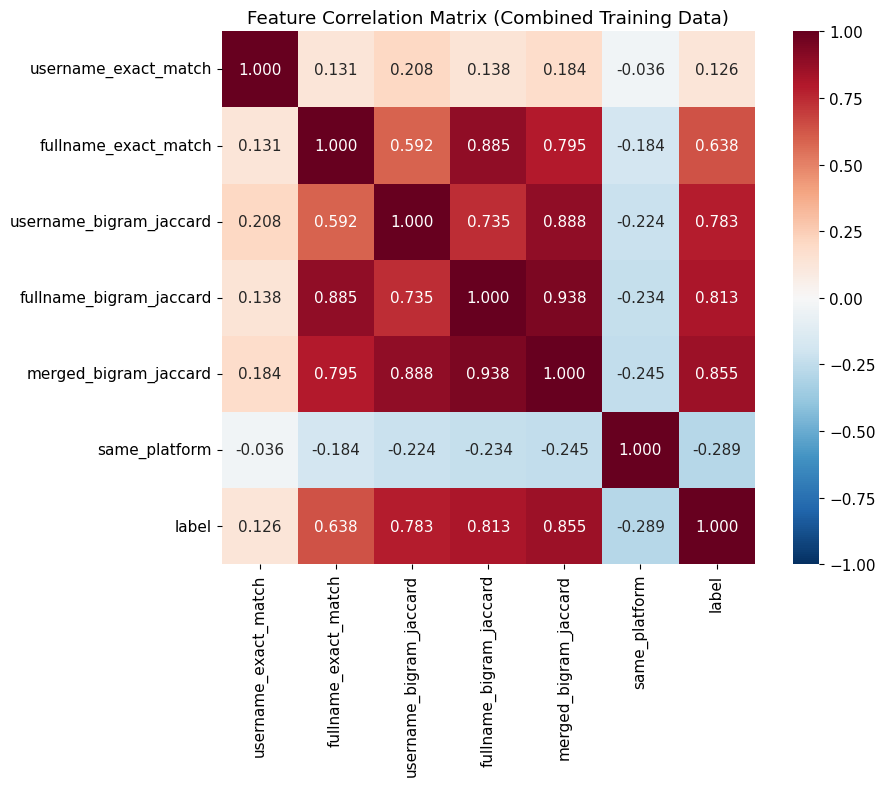

In [18]:
# Correlation matrix ของ features + label
corr_cols = combined_features + ["same_platform", "label"]
corr = combined[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0, 
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix (Combined Training Data)")
plt.tight_layout()
plt.show()

## 7. Summary

**ข้อมูลที่สร้าง:**
- **Per-pair flat CSVs**: n×n matrix แบน (ทุกคู่เปรียบเทียบ) สำหรับ Google_Insta, Google_Twitter, Insta_Twitter
- **Per-pair matrix CSVs**: n×n matrix แยกแต่ละ feature (label, exact match, bigram sim)
- **Combined training CSV**: รวมทุก platform, balanced sampling (positive + 5× negative)
- **Profile index CSV**: ข้อมูล profile ทั้งหมดพร้อม index

**Features:**
1. `username_exact_match` — username ตรงกันเป๊ะ (0/1)
2. `fullname_exact_match` — fullname ตรงกันเป๊ะ (0/1)
3. `username_bigram_jaccard` — Jaccard similarity ของ character bigrams ของ username
4. `fullname_bigram_jaccard` — Jaccard similarity ของ character bigrams ของ fullname
5. `merged_bigram_jaccard` — Jaccard similarity ของ bigrams รวม username+fullname
6. `same_platform` — อยู่ platform เดียวกันหรือไม่ (combined data เท่านั้น)

## 8. Combined Matrix รวมทุก Platform (ภาพรวม)

In [19]:
# 8.1 Platform-pair summary matrix (3×3 aggregate)
import pandas as pd

platforms = ["googlePlus", "instagram", "twitter"]

# คำนวณค่าเฉลี่ย similarity และ match rate ของแต่ละ platform pair
combined = pd.read_csv("combined_all_platforms_training.csv")

# map pair_source → (platform_a, platform_b)
pair_map = {
    "Google_Insta":   ("googlePlus", "instagram"),
    "Google_Twitter": ("googlePlus", "twitter"),
    "Insta_Twitter":  ("instagram",  "twitter"),
}

rows_summary = []
for pair_src, (pa, pb) in pair_map.items():
    sub = combined[combined["profile_a_pair_source"] == pair_src]
    pos = sub[sub["label"] == 1]
    neg = sub[sub["label"] == 0]
    rows_summary.append({
        "from": pa, "to": pb,
        "total_pairs": len(sub),
        "match_count": len(pos),
        "match_rate": len(pos) / len(sub) if len(sub) > 0 else 0,
        "avg_sim_pos": pos["merged_bigram_jaccard"].mean(),
        "avg_sim_neg": neg["merged_bigram_jaccard"].mean(),
    })

summary_df = pd.DataFrame(rows_summary)
display(summary_df.round(4))


,from,to,total_pairs,match_count,match_rate,avg_sim_pos,avg_sim_neg
0,googlePlus,instagram,7407,1228,0.1658,0.5584,0.0400
1,googlePlus,twitter,35682,5948,0.1667,0.5274,0.0397
2,instagram,twitter,29379,4902,0.1669,0.6603,0.0382


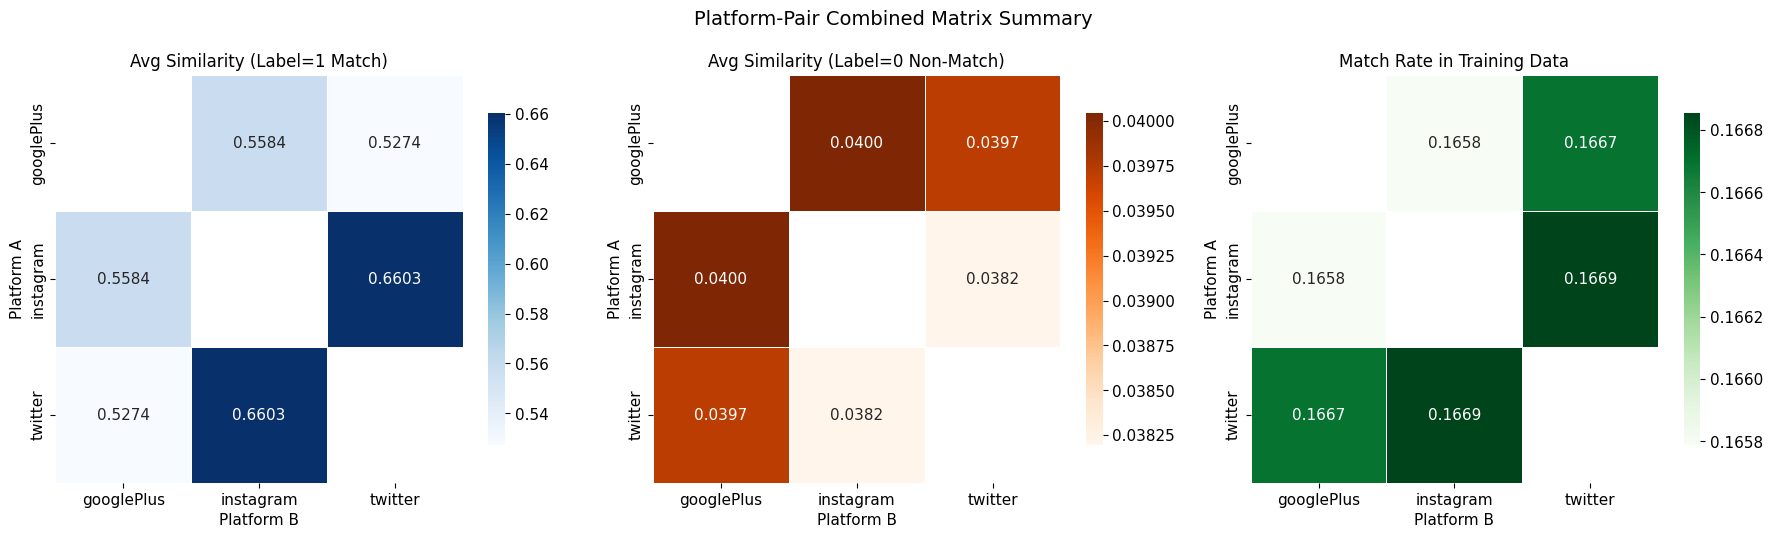

In [20]:
# 8.2 Heatmap แสดง Avg Similarity (Match vs Non-Match) แบบ 3×3 platform matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = [
    ("avg_sim_pos", "Avg Similarity (Label=1 Match)", "Blues"),
    ("avg_sim_neg", "Avg Similarity (Label=0 Non-Match)", "Oranges"),
    ("match_rate",  "Match Rate in Training Data",        "Greens"),
]

for ax, (metric, title, cmap) in zip(axes, metrics_to_plot):
    mat = pd.DataFrame(index=platforms, columns=platforms, dtype=float)
    for _, row in summary_df.iterrows():
        mat.loc[row["from"], row["to"]] = row[metric]
        mat.loc[row["to"],   row["from"]] = row[metric]  # symmetric
    np.fill_diagonal(mat.values.astype(float), np.nan)

    sns.heatmap(mat.astype(float), annot=True, fmt=".4f", cmap=cmap,
                ax=ax, square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8},
                mask=mat.isna())
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Platform B")
    ax.set_ylabel("Platform A")

plt.suptitle("Platform-Pair Combined Matrix Summary", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [21]:
# 8.3 Big combined profile matrix (subset) - แสดง merged_bigram_jaccard ของทุก positive pair
# จัด profiles เรียงตาม platform เพื่อให้เห็น block structure

prof_idx = pd.read_csv("combined_profile_index.csv")

# เอาเฉพาะ positive pairs
pos_pairs = combined[combined["label"] == 1].copy()

# สร้าง pivot table: rows=profile_a, cols=profile_b, values=merged_bigram_jaccard
# ใช้เฉพาะ positive เพื่อให้ matrix เล็กลง
pos_pivot = pos_pairs.pivot_table(
    index=["profile_a_idx", "profile_a_platform"],
    columns=["profile_b_idx", "profile_b_platform"],
    values="merged_bigram_jaccard",
    aggfunc="mean"
).fillna(0)

print(f"Positive pair pivot: {pos_pivot.shape}")

# สร้าง per-platform count matrix
platform_pairs_count = pd.crosstab(
    pos_pairs["profile_a_platform"],
    pos_pairs["profile_b_platform"],
    margins=True
)
print("\nPositive pairs count per platform pair:")
display(platform_pairs_count)


Positive pair pivot: (12078, 12078)

Positive pairs count per platform pair:


profile_b_platform,googlePlus,instagram,twitter,All
profile_a_platform,,,,
googlePlus,0,614,2974,3588
instagram,614,0,2451,3065
twitter,2974,2451,0,5425
All,3588,3065,5425,12078


In [24]:
# 8.4 สร้าง per-pair sub-matrix เรียงตาม folder → matches จะอยู่บน diagonal
pair_matrices = {}

for pair_src, (pa, pb) in pair_map.items():
    sub = combined[combined["profile_a_pair_source"] == pair_src].copy()
    pos = sub[sub["label"] == 1].copy()

    # ดึง profile list แต่ละ platform เรียงตาม folder (ชื่อคน)
    prof_a = (prof_idx[(prof_idx["platform"] == pa) & (prof_idx["pair_source"] == pair_src)]
              .sort_values("folder")
              .reset_index(drop=True))
    prof_b = (prof_idx[(prof_idx["platform"] == pb) & (prof_idx["pair_source"] == pair_src)]
              .sort_values("folder")
              .reset_index(drop=True))

    # idx → row/col position
    a_pos = {row["idx"]: i for i, row in prof_a.iterrows()}
    b_pos = {row["idx"]: i for i, row in prof_b.iterrows()}

    na, nb = len(prof_a), len(prof_b)
    mat = np.zeros((na, nb), dtype=np.float32)

    for _, row in sub.iterrows():
        i = a_pos.get(row["profile_a_idx"])
        j = b_pos.get(row["profile_b_idx"])
        if i is not None and j is not None:
            mat[i, j] = row["merged_bigram_jaccard"] if row["label"] == 1 else (row["merged_bigram_jaccard"] * 0.3)

    pair_matrices[pair_src] = {
        "mat": mat, "prof_a": prof_a, "prof_b": prof_b,
        "pa": pa, "pb": pb,
        "pos_count": len(pos),
    }
    print(f"{pair_src}: {na} {pa} × {nb} {pb}, positive={len(pos)}")


Google_Insta: 614 googlePlus × 614 instagram, positive=1228
Google_Twitter: 2974 googlePlus × 2974 twitter, positive=5948
Insta_Twitter: 2451 instagram × 2451 twitter, positive=4902


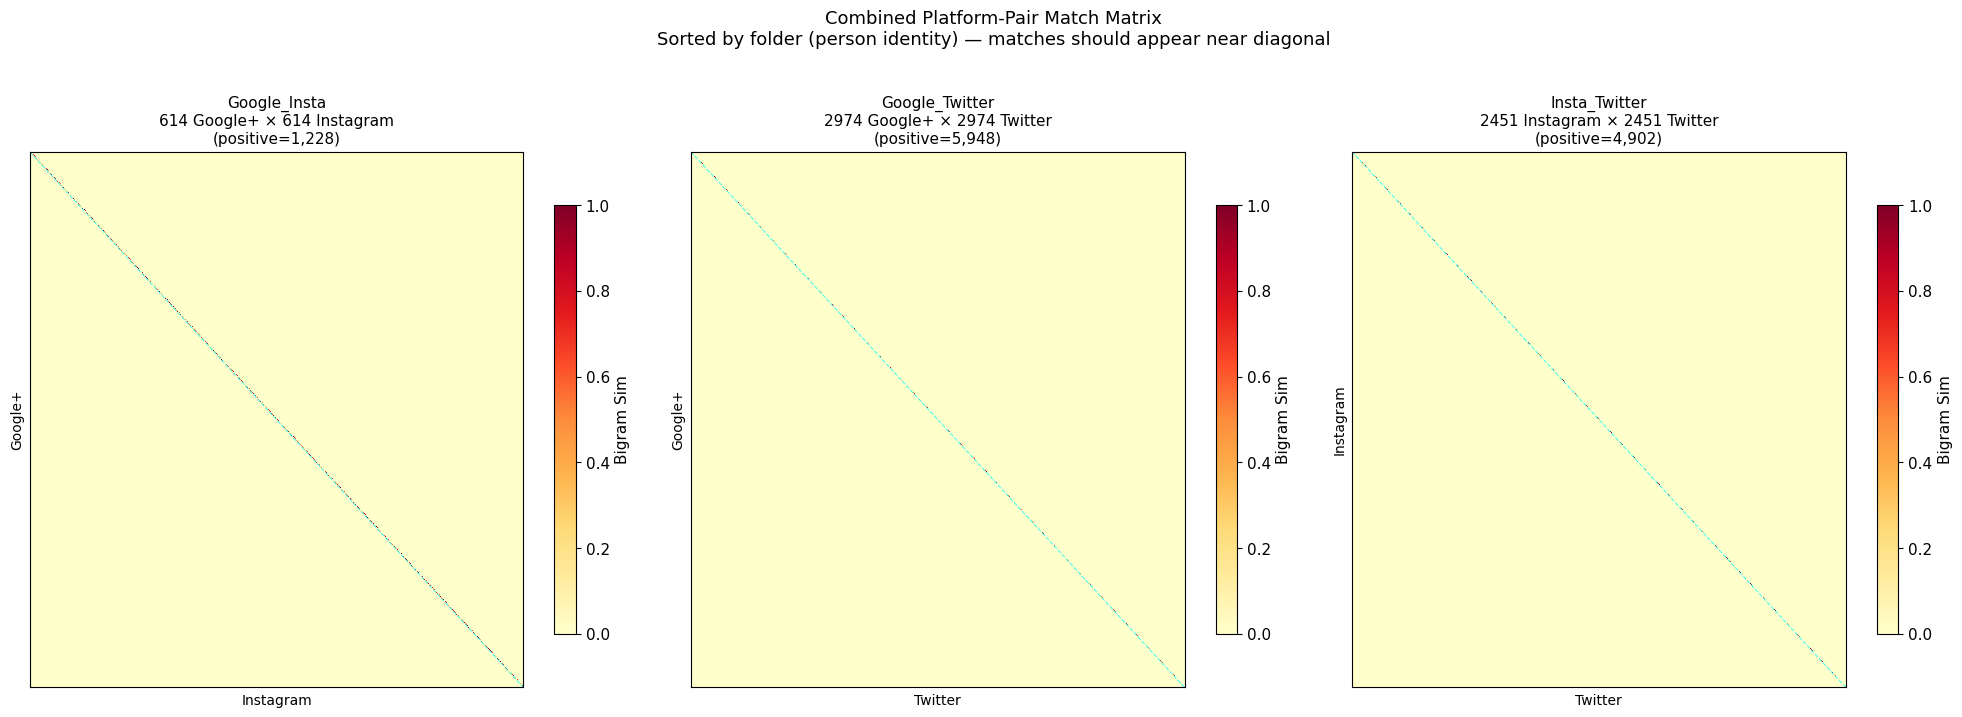

In [25]:
# 8.5 Combined matrix view - แสดง 3 platform-pair blocks แบบ grid
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

pair_labels = {
    "Google_Insta":   ("Google+", "Instagram"),
    "Google_Twitter": ("Google+", "Twitter"),
    "Insta_Twitter":  ("Instagram", "Twitter"),
}

for ax, (pair_src, info) in zip(axes, pair_matrices.items()):
    mat = info["mat"]
    la, lb = pair_labels[pair_src]

    im = ax.imshow(mat, cmap="YlOrRd", aspect="auto",
                   interpolation="none", vmin=0, vmax=1)

    # วาดเส้น diagonal (ตำแหน่ง ground truth match)
    diag_n = min(mat.shape)
    ax.plot([0, diag_n - 1], [0, diag_n - 1],
            color="cyan", linewidth=0.8, alpha=0.7, linestyle="--", label="Expected diagonal")

    ax.set_title(f"{pair_src}\n{mat.shape[0]} {la} × {mat.shape[1]} {lb}\n"
                 f"(positive={info['pos_count']:,})", fontsize=11)
    ax.set_xlabel(lb, fontsize=10)
    ax.set_ylabel(la, fontsize=10)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.colorbar(im, ax=ax, label="Bigram Sim", shrink=0.8)

plt.suptitle("Combined Platform-Pair Match Matrix\n"
             "Sorted by folder (person identity) — matches should appear near diagonal",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 9. เตรียมข้อมูล Negative-Only Upper Triangle สำหรับ Training

In [26]:
# 9.1 โหลด per-pair flat data → filter negative → upper triangle
import os

out_dir = "negative_upper_triangle"
os.makedirs(out_dir, exist_ok=True)

all_neg_upper = []

for pair_src, (pa, pb) in pair_map.items():
    path = f"{pair_src}/{pair_src}_training_flat.csv"
    df = pd.read_csv(path, low_memory=False)

    # ดูชื่อ column ของ idx แต่ละ platform
    idx_col_a = f"{pa}_idx"
    idx_col_b = f"{pb}_idx"

    print(f"\n{pair_src} — columns: {[c for c in df.columns if 'idx' in c]}")
    print(f"  Total: {len(df):,} | Positive: {(df['label']==1).sum():,} | Negative: {(df['label']==0).sum():,}")

    # Filter เฉพาะ negative
    neg = df[df["label"] == 0].copy()

    # Upper triangle: idx_a < idx_b (เอาแค่ครึ่งบน ไม่มีคู่ซ้ำ)
    upper = neg[neg[idx_col_a] < neg[idx_col_b]].copy()
    upper["pair_source"] = pair_src

    print(f"  After upper triangle filter: {len(upper):,} rows (จาก {len(neg):,} negatives)")

    # Save แยกแต่ละ pair
    out_path = f"{out_dir}/{pair_src}_negative_upper.csv"
    upper.to_csv(out_path, index=False)
    print(f"  Saved → {out_path}")

    all_neg_upper.append(upper)



Google_Insta — columns: ['googlePlus_idx', 'instagram_idx']
  Total: 376,996 | Positive: 614 | Negative: 376,382
  After upper triangle filter: 188,191 rows (จาก 376,382 negatives)
  Saved → negative_upper_triangle/Google_Insta_negative_upper.csv

Google_Twitter — columns: ['googlePlus_idx', 'twitter_idx']
  Total: 8,844,676 | Positive: 2,974 | Negative: 8,841,702
  After upper triangle filter: 4,420,851 rows (จาก 8,841,702 negatives)
  Saved → negative_upper_triangle/Google_Twitter_negative_upper.csv

Insta_Twitter — columns: ['instagram_idx', 'twitter_idx']
  Total: 6,007,401 | Positive: 2,451 | Negative: 6,004,950
  After upper triangle filter: 3,002,475 rows (จาก 6,004,950 negatives)
  Saved → negative_upper_triangle/Insta_Twitter_negative_upper.csv


In [27]:
# 9.2 รวมทุก pair เป็นไฟล์เดียว + summary
combined_neg = pd.concat(all_neg_upper, ignore_index=True)

print(f"Combined negative upper triangle: {len(combined_neg):,} rows")
print(f"\nBreakdown by pair:")
print(combined_neg["pair_source"].value_counts())

out_all = f"{out_dir}/all_pairs_negative_upper.csv"
combined_neg.to_csv(out_all, index=False)
print(f"\nSaved combined → {out_all}")
print(f"File size: {os.path.getsize(out_all) / 1e6:.1f} MB")


Combined negative upper triangle: 7,611,517 rows

Breakdown by pair:
pair_source
Google_Twitter    4420851
Insta_Twitter     3002475
Google_Insta       188191
Name: count, dtype: int64

Saved combined → negative_upper_triangle/all_pairs_negative_upper.csv
File size: 1135.0 MB


## 10. สร้าง Final Training Set (ตัด hard cases + balance)

In [28]:
# 10.1 ตัด hard cases ออก (merged_bigram_jaccard < 0.05)
combined = pd.read_csv("combined_all_platforms_training.csv")

pos_all = combined[combined["label"] == 1]
neg_all = combined[combined["label"] == 0]

THRESHOLD = 0.05
pos_clean = pos_all[pos_all["merged_bigram_jaccard"] >= THRESHOLD].copy()

cut = len(pos_all) - len(pos_clean)
print(f"Positive pairs ทั้งหมด : {len(pos_all):,}")
print(f"ตัดออก (sim < {THRESHOLD}) : {cut:,}")
print(f"Positive pairs เหลือ   : {len(pos_clean):,}")
print(f"\nBreakdown by pair_source:")
print(pos_clean["profile_a_pair_source"].value_counts())


Positive pairs ทั้งหมด : 12,078
ตัดออก (sim < 0.05) : 636
Positive pairs เหลือ   : 11,442

Breakdown by pair_source:
profile_a_pair_source
Google_Twitter    5510
Insta_Twitter     4786
Google_Insta      1146
Name: count, dtype: int64


In [29]:
# 10.2 Sample negative ให้ได้ ratio 1:5 (ต่อ pair_source)
RATIO = 5
neg_sampled_list = []

for pair_src in pos_clean["profile_a_pair_source"].unique():
    pos_sub = pos_clean[pos_clean["profile_a_pair_source"] == pair_src]
    neg_sub = neg_all[neg_all["profile_a_pair_source"] == pair_src]
    n_sample = min(len(pos_sub) * RATIO, len(neg_sub))
    neg_sampled_list.append(neg_sub.sample(n_sample, random_state=42))
    print(f"{pair_src}: pos={len(pos_sub):,}  neg_sampled={n_sample:,}")

neg_sampled = pd.concat(neg_sampled_list, ignore_index=True)

# รวม positive + negative
final_df = pd.concat([pos_clean, neg_sampled], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal training set: {len(final_df):,} rows")
print(f"  label=1 : {(final_df['label']==1).sum():,}")
print(f"  label=0 : {(final_df['label']==0).sum():,}")
print(f"  ratio   : 1:{(final_df['label']==0).sum() // (final_df['label']==1).sum()}")


Insta_Twitter: pos=4,786  neg_sampled=23,930
Google_Insta: pos=1,146  neg_sampled=5,730
Google_Twitter: pos=5,510  neg_sampled=27,550

Final training set: 68,652 rows
  label=1 : 11,442
  label=0 : 57,210
  ratio   : 1:5


In [33]:
# 10.3 Strict folder-based split + re-sample negatives จาก upper triangle (pool ใหญ่)
from sklearn.model_selection import train_test_split

# รวม folders จากทั้ง 2 ฝั่ง
all_folders = pd.Index(pos_clean["profile_a_folder"].unique()).union(
              pos_clean["profile_b_folder"].dropna().unique())

train_f, temp_f = train_test_split(all_folders, test_size=0.3, random_state=42)
val_f,   test_f = train_test_split(temp_f,       test_size=0.5, random_state=42)
train_f, val_f, test_f = set(train_f), set(val_f), set(test_f)

# โหลด negative pool จาก upper triangle ไฟล์ใหญ่ (มี folder ทั้ง 2 ฝั่ง)
print("Loading negative upper triangle pools...")
neg_pools = {}
for pair_src, (pa, pb) in pair_map.items():
    path = f"negative_upper_triangle/{pair_src}_negative_upper.csv"
    cols_needed = [f"{pa}_folder", f"{pb}_folder",
                   "username_exact_match", "fullname_exact_match",
                   "username_bigram_jaccard", "fullname_bigram_jaccard",
                   "merged_bigram_jaccard", "label"]
    df = pd.read_csv(path, usecols=cols_needed, low_memory=False)
    # rename ให้ตรงกับ combined format
    df = df.rename(columns={f"{pa}_folder": "profile_a_folder", f"{pb}_folder": "profile_b_folder"})
    df["profile_a_platform"] = pa
    df["profile_b_platform"] = pb
    df["profile_a_pair_source"] = pair_src
    df["same_platform"] = 0
    neg_pools[pair_src] = df
    print(f"  {pair_src}: {len(df):,} rows")

neg_big = pd.concat(neg_pools.values(), ignore_index=True)
print(f"Total negative pool: {len(neg_big):,}")

def make_split(pos_df, neg_pool, folder_set, ratio=5, seed=42):
    pos = pos_df[
        pos_df["profile_a_folder"].isin(folder_set) &
        pos_df["profile_b_folder"].isin(folder_set)
    ].copy()
    neg = neg_pool[
        neg_pool["profile_a_folder"].isin(folder_set) &
        neg_pool["profile_b_folder"].isin(folder_set)
    ]
    n_neg = min(len(pos) * ratio, len(neg))
    neg_s = neg.sample(n_neg, random_state=seed)
    # เลือกเฉพาะ feature columns + label ที่มีร่วมกัน
    feat_cols = ["profile_a_platform", "profile_b_platform",
                 "profile_a_folder", "profile_b_folder",
                 "username_exact_match", "fullname_exact_match",
                 "username_bigram_jaccard", "fullname_bigram_jaccard",
                 "merged_bigram_jaccard", "same_platform", "label"]
    pos_s = pos[[c for c in feat_cols if c in pos.columns]]
    neg_s = neg_s[[c for c in feat_cols if c in neg_s.columns]]
    df = pd.concat([pos_s, neg_s], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df

train_df = make_split(pos_clean, neg_big, train_f, ratio=5)
val_df   = make_split(pos_clean, neg_big, val_f,   ratio=5)
test_df  = make_split(pos_clean, neg_big, test_f,  ratio=5)

for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    pos_n = (df["label"]==1).sum()
    neg_n = (df["label"]==0).sum()
    print(f"{name:5}: {len(df):>6,} rows  pos={pos_n:,}  neg={neg_n:,}  ratio=1:{neg_n//pos_n}")

# ตรวจ leakage
overlap_a = set(train_df["profile_a_folder"]) & set(test_df["profile_a_folder"])
overlap_b = set(train_df["profile_b_folder"]) & set(test_df["profile_b_folder"])
print(f"\nLeakage (a): {len(overlap_a)}  |  (b): {len(overlap_b)}  ← ควรเป็น 0")

# Save
import os
out_dir = "final_training"
os.makedirs(out_dir, exist_ok=True)
train_df.to_csv(f"{out_dir}/train.csv", index=False)
val_df.to_csv(  f"{out_dir}/val.csv",   index=False)
test_df.to_csv( f"{out_dir}/test.csv",  index=False)
pd.concat([train_df, val_df, test_df], ignore_index=True).to_csv(f"{out_dir}/all.csv", index=False)
print(f"Saved → {out_dir}/  (train / val / test / all)")


Loading negative upper triangle pools...
  Google_Insta: 188,191 rows
  Google_Twitter: 4,420,851 rows
  Insta_Twitter: 3,002,475 rows
Total negative pool: 7,611,517
Train: 48,048 rows  pos=8,008  neg=40,040  ratio=1:5
Val  : 10,296 rows  pos=1,716  neg=8,580  ratio=1:5
Test : 10,308 rows  pos=1,718  neg=8,590  ratio=1:5

Leakage (a): 0  |  (b): 0  ← ควรเป็น 0
Saved → final_training/  (train / val / test / all)
